In [1]:
import numpy as np

loaded_nu_training_arrays = np.load("/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TriggerTrainingData/pdvd_trigger_training_binned_data/pdvd_trigger_training_neutrino_binned_mar2026.npz")
loaded_cosmic_training_arrays = np.load("/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TriggerTrainingData/pdvd_trigger_training_binned_data/pdvd_trigger_training_cosmic_binned_mar2026.npz")

nu_images_plane0 = loaded_nu_training_arrays["plane0"]
nu_images_plane1 = loaded_nu_training_arrays["plane1"]
nu_images_plane2 = loaded_nu_training_arrays["plane2"]

cosmic_images_plane0 = loaded_cosmic_training_arrays["plane0"]
cosmic_images_plane1 = loaded_cosmic_training_arrays["plane1"]
cosmic_images_plane2 = loaded_cosmic_training_arrays["plane2"]

print(f'nu array plane 2 shape = {nu_images_plane2.shape}')
print(f'cosmic plane 2 array shape = {cosmic_images_plane2.shape}')

nu array plane 2 shape = (19539, 10, 10)
cosmic plane 2 array shape = (263001, 10, 10)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from hist import Hist
import hist
import mplhep as hep
from matplotlib.backends.backend_pdf import PdfPages
from cycler import cycler
import matplotlib.ticker as ticker

plt.style.use(hep.style.DUNE)
hep.style.use(["DUNE", {"axes.prop_cycle": cycler("color", 
                                                  ["#D55E00",  # DUNE Orange (primary)
                                                   "#56B4E9",  # DUNE Sky Blue (primary)
                                                   "#009E73",  # Green (accessible)
                                                   "#E69F00",  # DUNE Yellow/Gold (primary)
                                                   "#CC79A7",  # Pink (accessible)
                                                   "#0072B2",  # Blue (accessible)
                                                   "#F0E442",  # Bright Yellow (accessible)
                                                  ])} ])

def plot_2D_xgboost_training_data(data, n_time_bins, n_chan_bins, n_to_plot=10, savename='plots.pdf'):
    with PdfPages(savename) as pdf: 
        for i in range(n_to_plot):    
            fig, axs = plt.subplots(1, 2, figsize=(15, 4))
        
            counts = data[i]
            counts_flat = counts.reshape(-1, order='C')
        
            h1 = Hist.new.Reg(n_chan_bins*n_time_bins, 0, n_chan_bins*n_time_bins, name="time_chan", label='Channel x Time Bin Number').Double()
        
            h1.view(flow=False)[:] = counts_flat
            
            hep.histplot(h1, histtype='fill', ax=axs[0])
            axs[0].margins(y=0.05)
            axs[0].set_ylabel('SADC (ADC)')
        
            h2 = Hist.new.Reg(n_chan_bins, 0, n_chan_bins, name="channel", label="Channel Bin Number")\
                   .Reg(n_time_bins, 0, n_time_bins, name="time", label="Time Bin Number")\
                   .Double()
        
            h2.view(flow=False)[:, :] = counts
            
            hep.dune.label(f': Cosmic Training Sample', rlabel='', fontsize=12, exp='ProtoDUNE-VD', ax=axs[1], data=False) 
            #plt.colorbar().ax.set_ylabel('SADC (ADC)')
            #axs[1].set_zlabel('SADC (ADC)')
        
            hep.hist2dplot(h2, ax=axs[1])
            
            pdf.savefig()
            
            plt.show()
      
def plot_2D_image_only_xgboost_training_data(data, n_time_bins, n_chan_bins, n_to_plot=10, savename='plots.pdf'):
    with PdfPages(savename) as pdf: 
        for i in range(n_to_plot):    
            fig, axs = plt.subplots(1, 1, figsize=(8, 5))
        
            counts = data[i]
        
            h2 = Hist.new.Reg(n_chan_bins, 0, n_chan_bins, name="channel", label="Channel Bin Number")\
                   .Reg(n_time_bins, 0, n_time_bins, name="time", label="Time Bin Number")\
                   .Double()
        
            h2.view(flow=False)[:, :] = counts
            
            hep.dune.label(f': Neutrino Sample', rlabel='DUNE work-in-progress', fontsize=12, exp='ProtoDUNE-VD', ax=axs, data=False) 
        
            image = hep.hist2dplot(h2, ax=axs)
            print(type(image), image)
            cbar = image.cbar

            cbar.set_label("Charge [ADC]")
            formatter = ticker.ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((0, 0))   # always use scientific notation

            cbar.formatter = formatter
            cbar.update_ticks()
            
            pdf.savefig()
            
            plt.show()

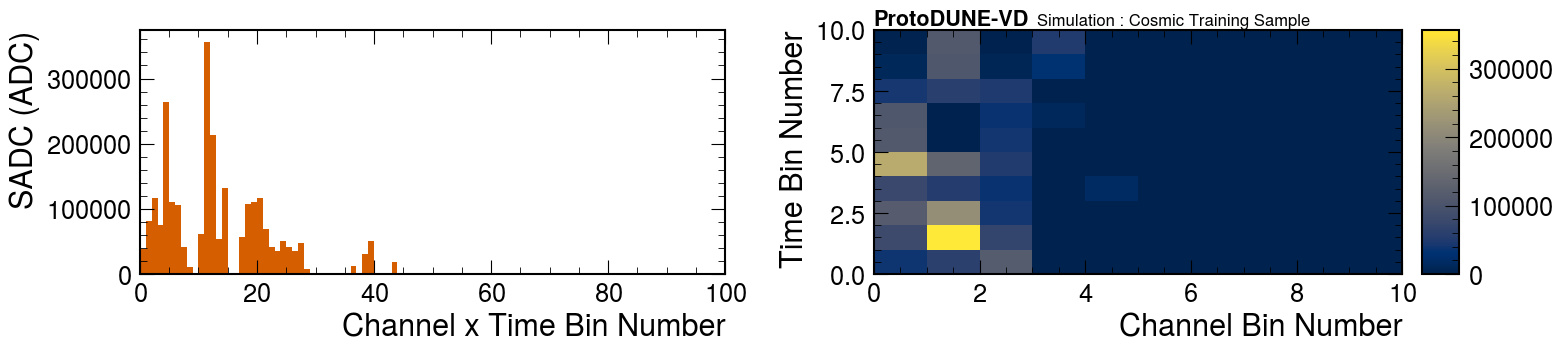

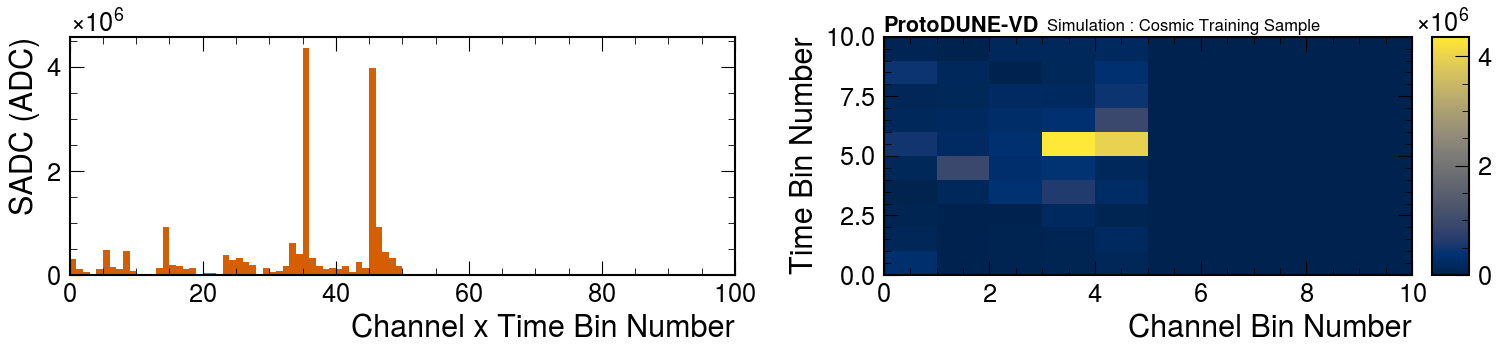

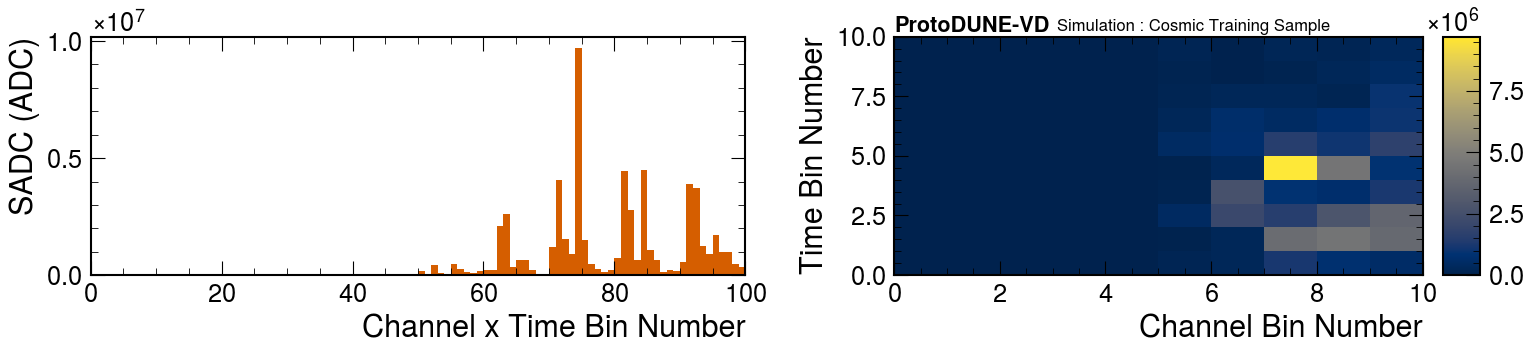

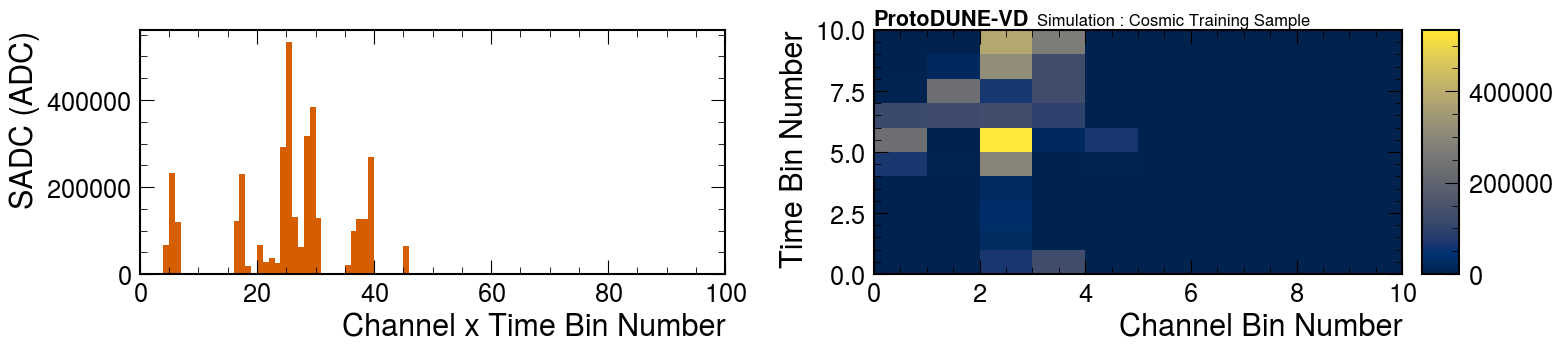

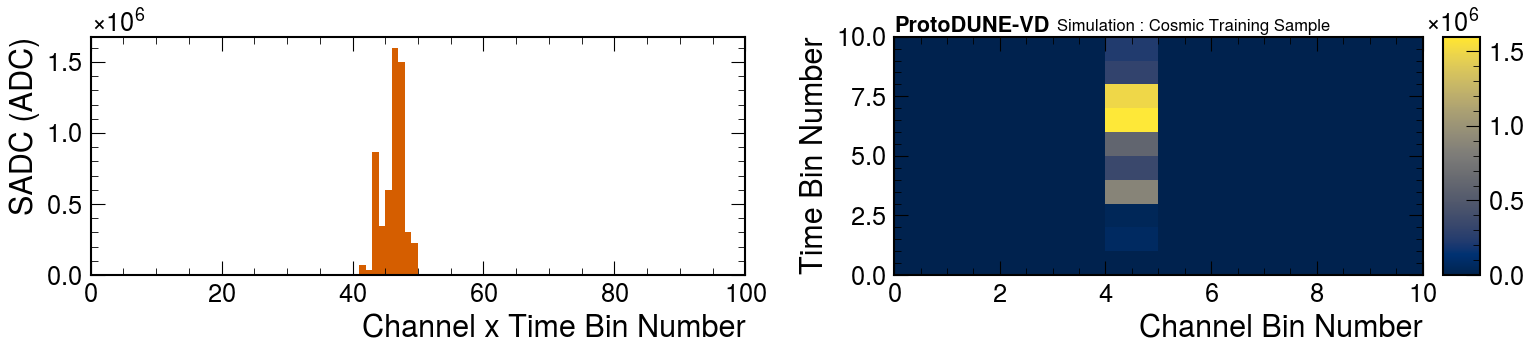

In [116]:
plot_2D_xgboost_training_data(nu_images_plane2, nu_images_plane2.shape[1], nu_images_plane2.shape[2], 
                              n_to_plot=5, savename='/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_updated_loading_windows_neutrinos_Feb2026.pdf')

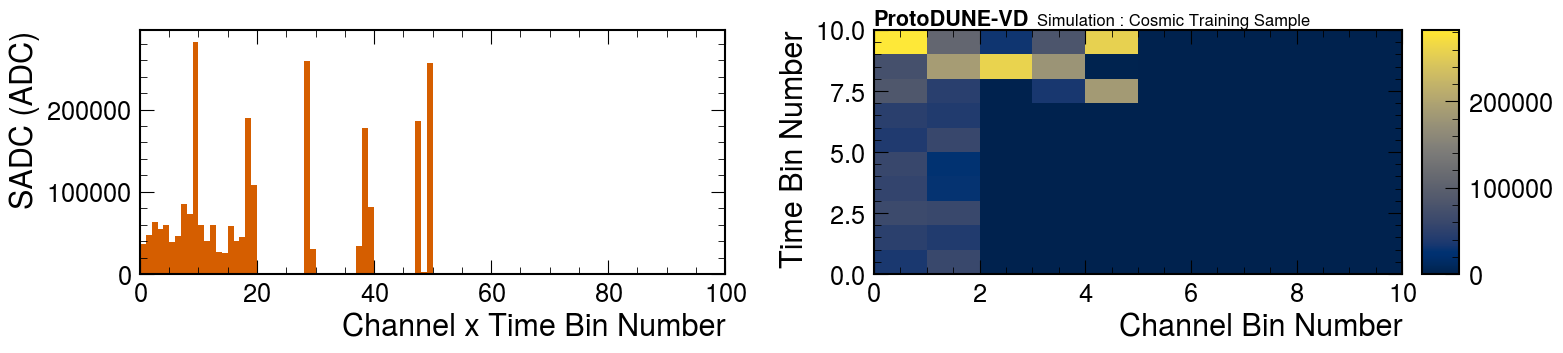

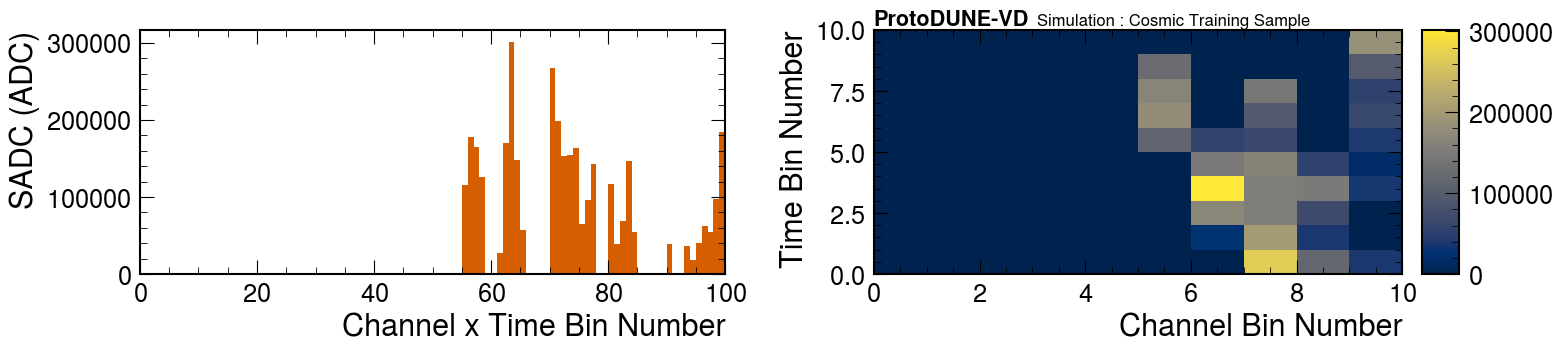

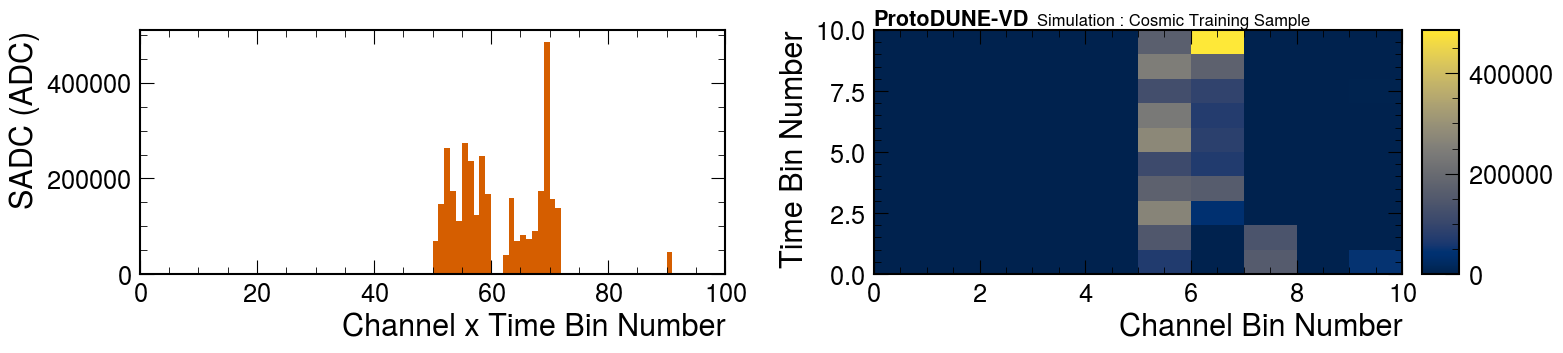

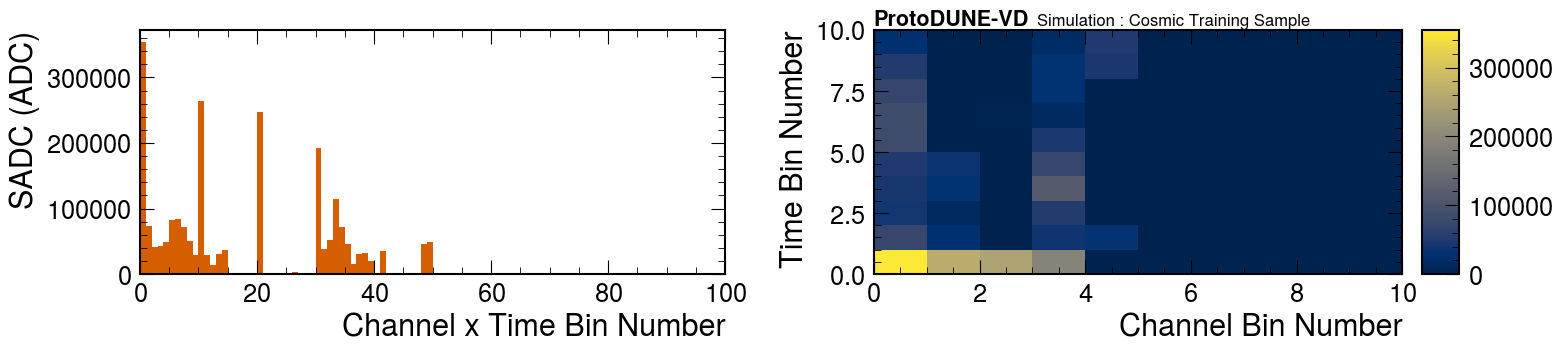

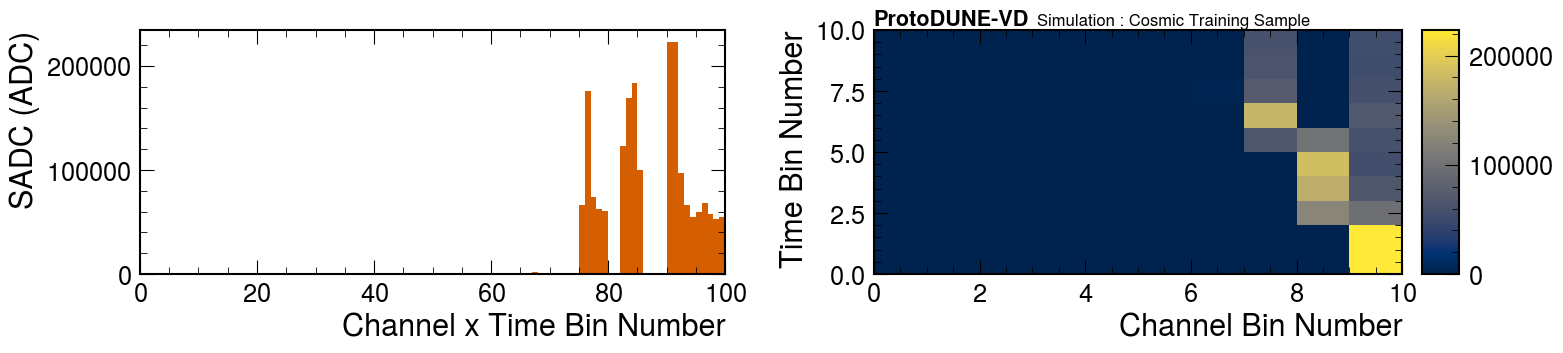

In [117]:
plot_2D_xgboost_training_data(cosmic_images_plane2, cosmic_images_plane2.shape[1], cosmic_images_plane2.shape[2], 
                              n_to_plot=5, savename='/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_updated_loading_cosmic_windows_Feb2026.pdf')

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9f8701430>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd9eaf0f470>, text=[])


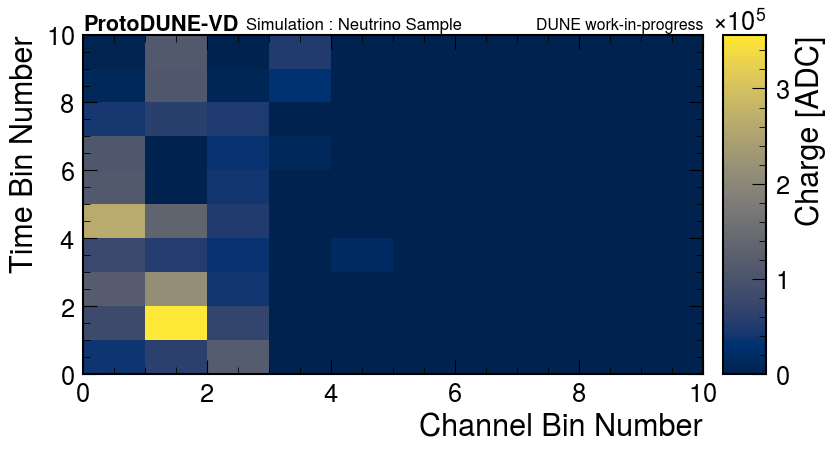

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda10b74500>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10305e50>, text=[])


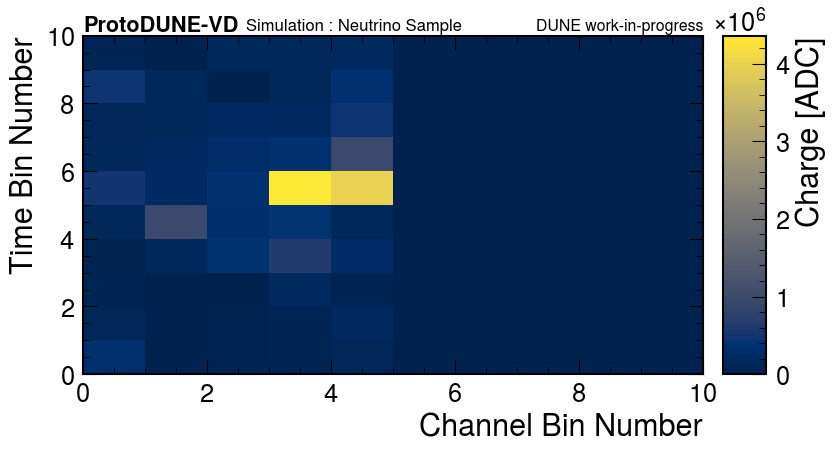

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda10acb830>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10d31a30>, text=[])


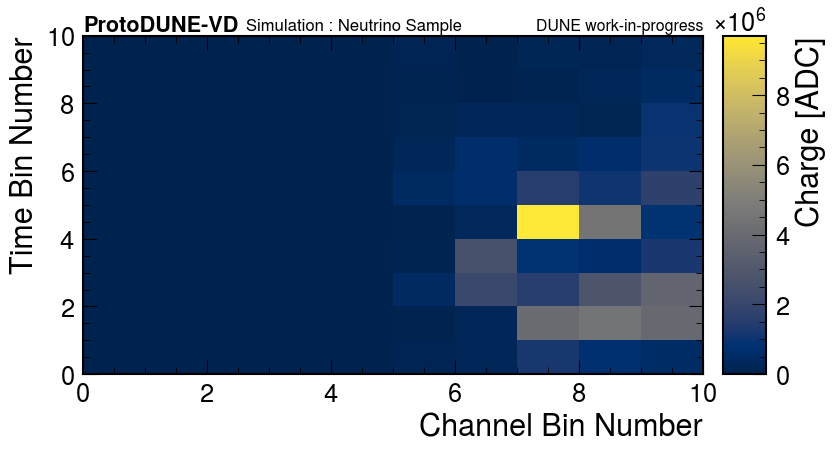

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9ea789c70>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda0f464740>, text=[])


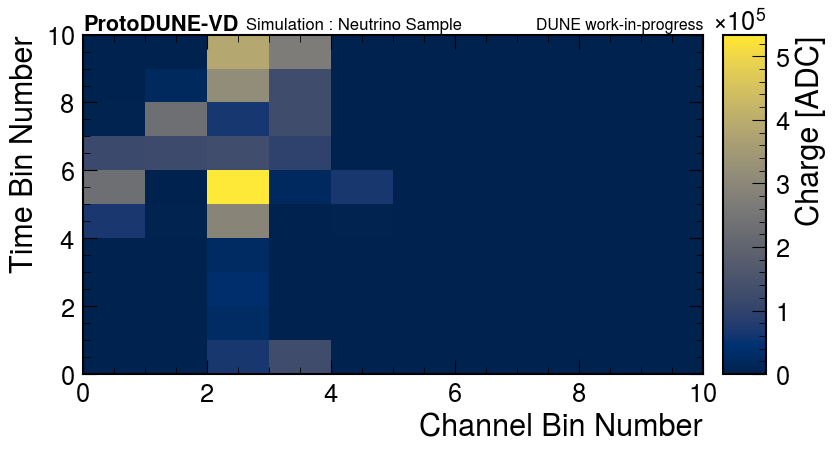

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9eae9d820>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10c97b30>, text=[])


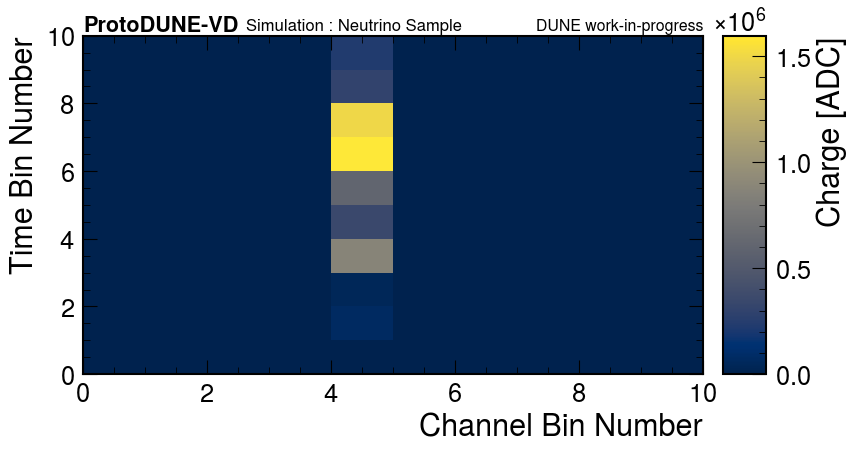

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda10b28a70>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10443650>, text=[])


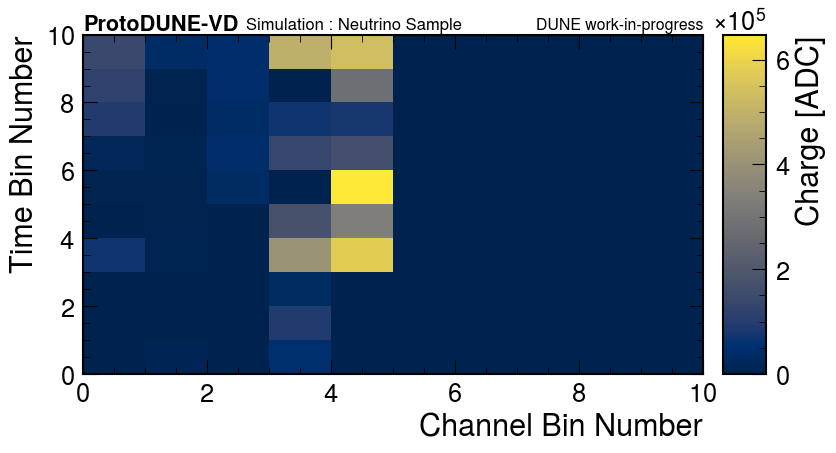

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9ea8eca10>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10a98980>, text=[])


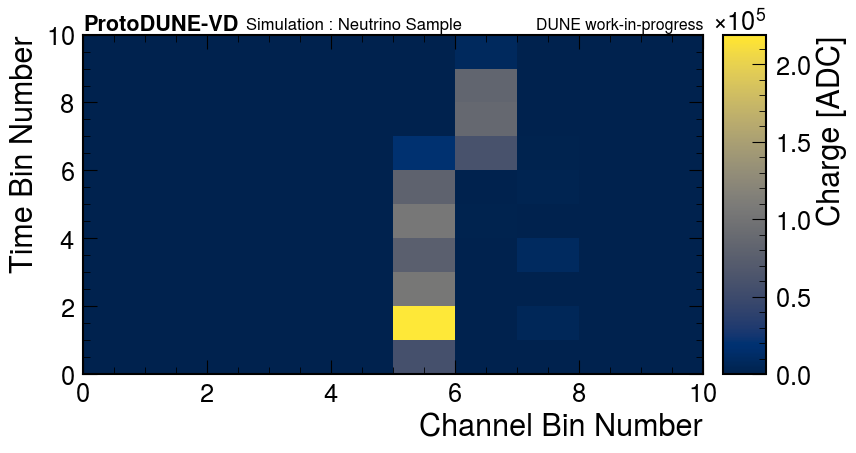

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda1057d370>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd9eabad550>, text=[])


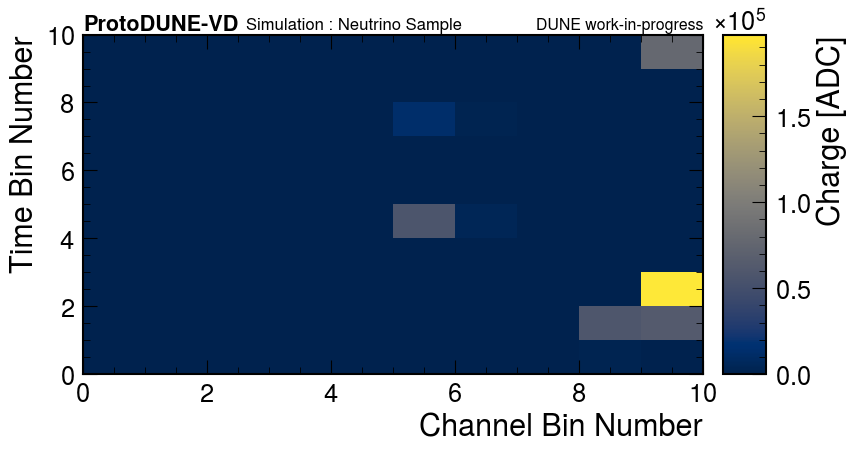

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9ea9a6270>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda105d4a40>, text=[])


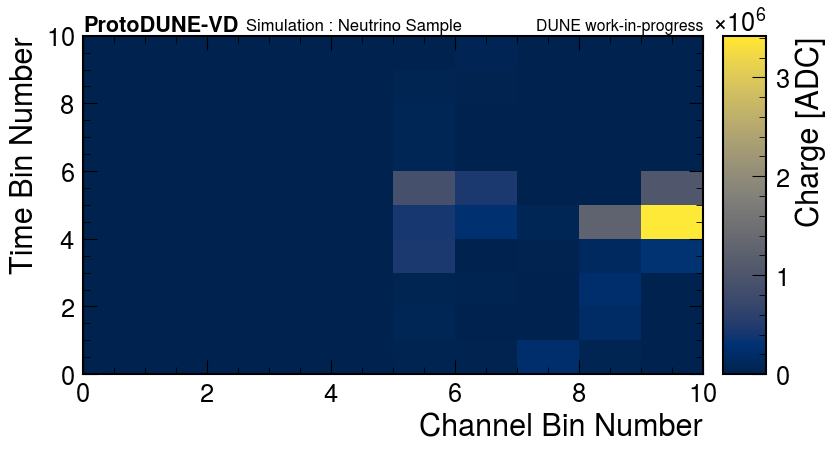

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9ea971bb0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10a06120>, text=[])


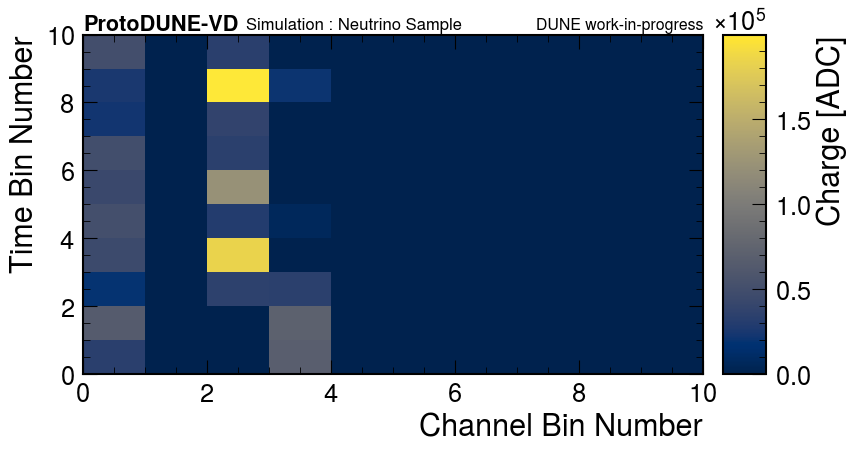

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda10bf24b0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd9eaadd6a0>, text=[])


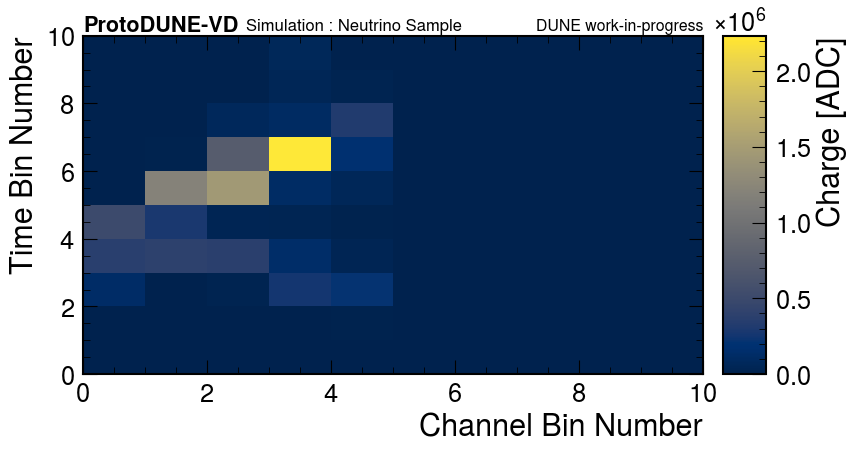

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda10d30a10>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda0f4d54c0>, text=[])


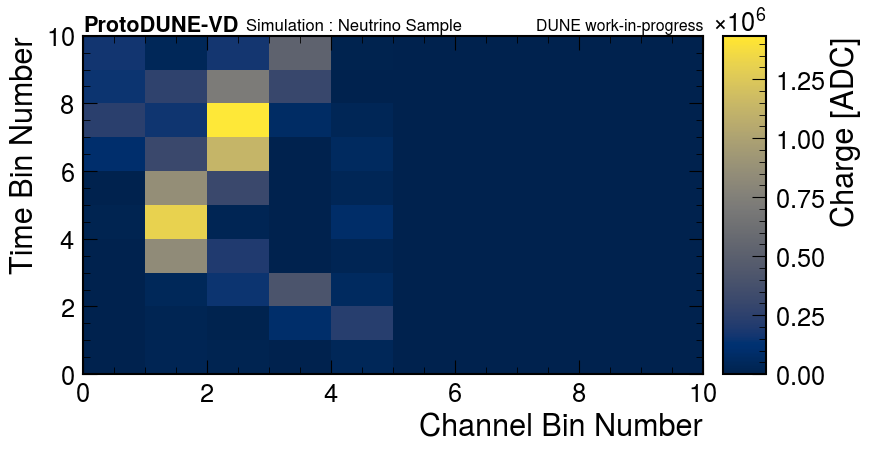

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9ead72240>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10a11c40>, text=[])


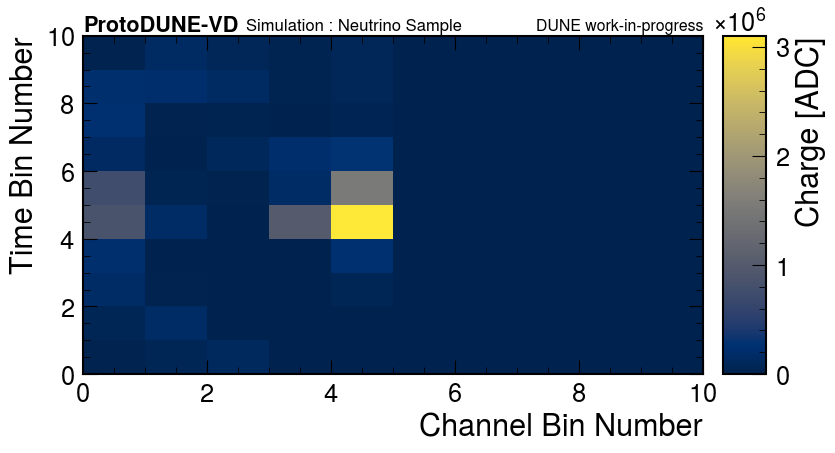

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9f8e5c3e0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd9f8a5ca40>, text=[])


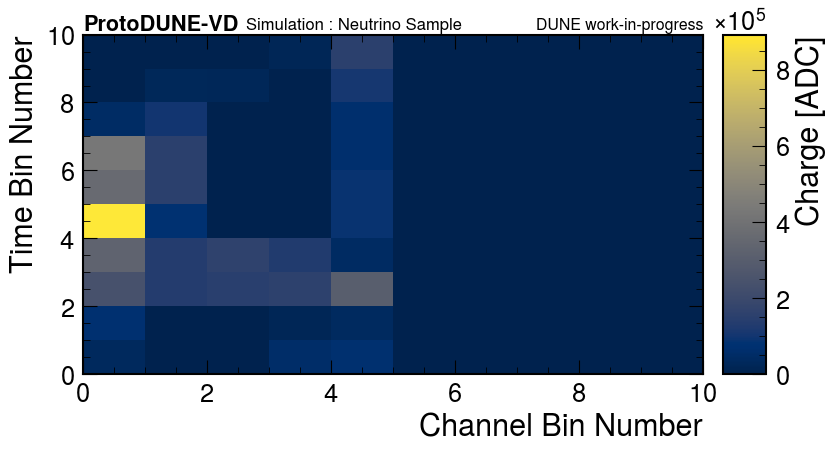

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9f8943440>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda106e1bb0>, text=[])


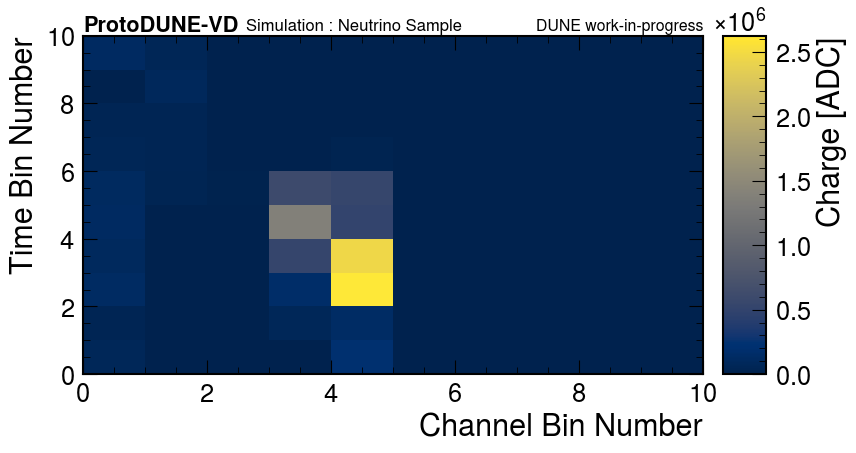

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda0f426750>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10c970e0>, text=[])


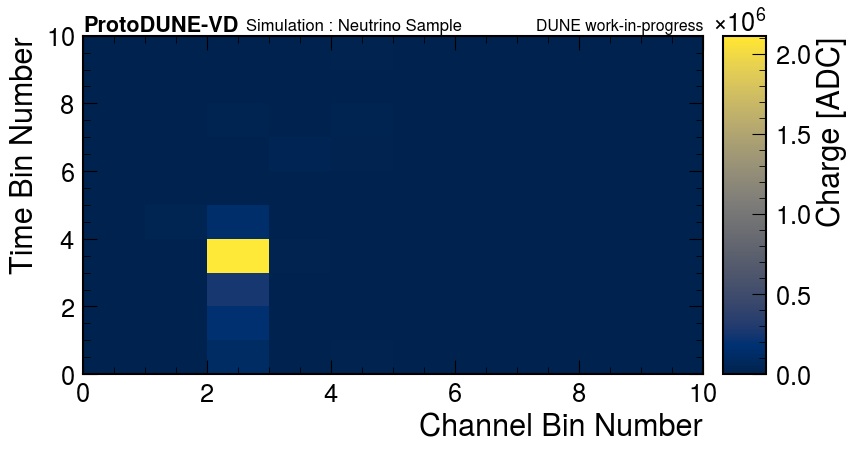

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fda10dab830>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda10502b70>, text=[])


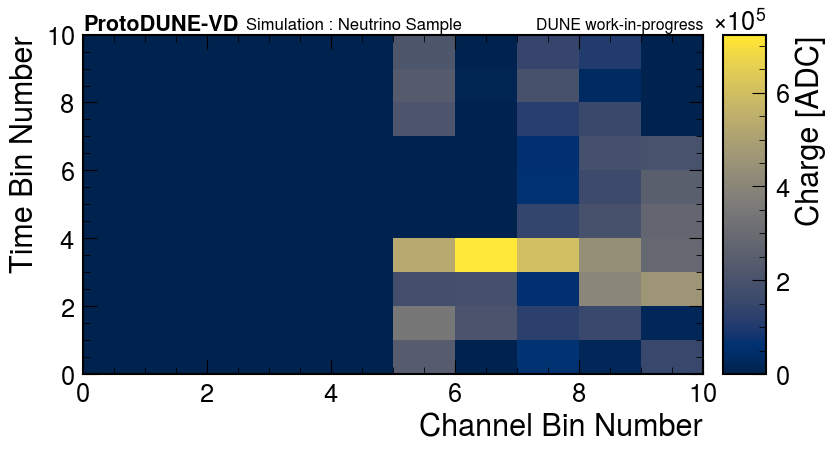

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9eaade270>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fda0f302720>, text=[])


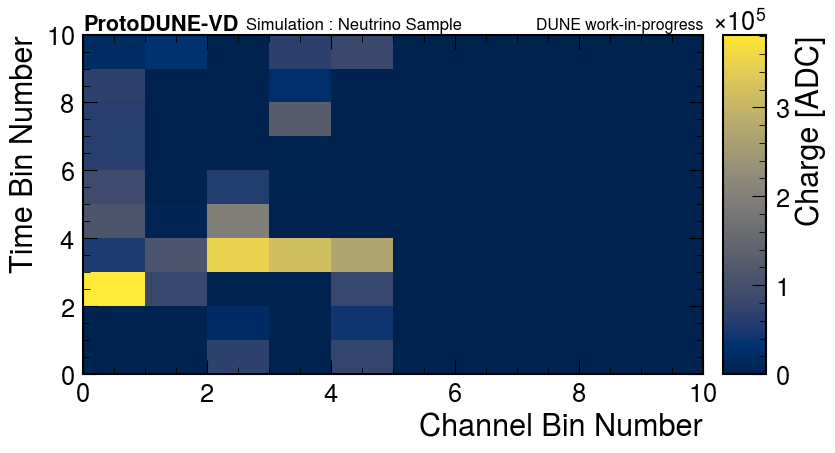

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9ea973530>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd9ead856a0>, text=[])


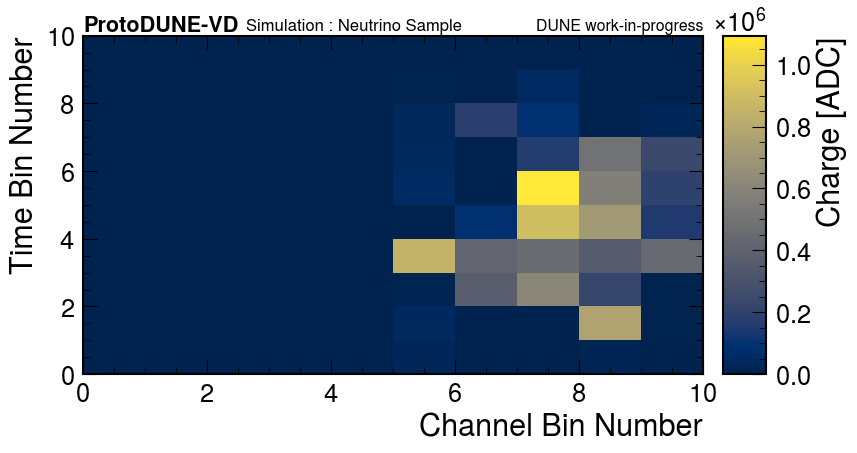

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd9eafa6750>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd9eabacfe0>, text=[])


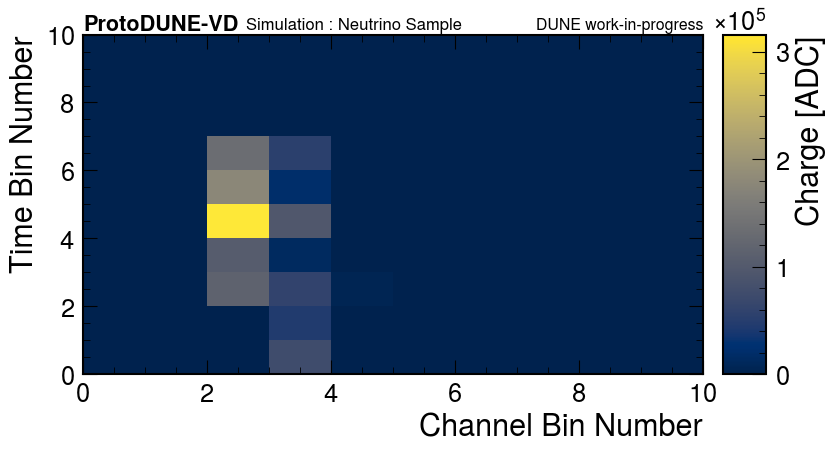

In [118]:
plot_2D_image_only_xgboost_training_data(nu_images_plane2, nu_images_plane2.shape[1], nu_images_plane2.shape[2], 
                              n_to_plot=20, savename='/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_updated_loading_windows_neutrinos_2D_only_WIPlabel_Feb2026.pdf')

In [3]:
# Split samples into training and testing samples
from sklearn.model_selection import train_test_split

Y_cos_nu_plane0_total = np.array([0]*len(cosmic_images_plane0) + [1]*len(nu_images_plane0))
Y_cos_nu_plane1_total = np.array([0]*len(cosmic_images_plane1) + [1]*len(nu_images_plane1))
Y_cos_nu_plane2_total = np.array([0]*len(cosmic_images_plane2) + [1]*len(nu_images_plane2))

X_features_plane0_total = np.vstack([cosmic_images_plane0, nu_images_plane0])
X_features_plane1_total = np.vstack([cosmic_images_plane1, nu_images_plane1])
X_features_plane2_total = np.vstack([cosmic_images_plane2, nu_images_plane2])

# I need to shuffle the training data in the same way for all planes
# Use a permutation
N = len(X_features_plane0_total)
perm = np.random.permutation(N)

Y_cos_nu_plane0_total = Y_cos_nu_plane0_total[perm]
Y_cos_nu_plane1_total = Y_cos_nu_plane1_total[perm]
Y_cos_nu_plane2_total = Y_cos_nu_plane2_total[perm]

X_features_plane0_total = X_features_plane0_total[perm]
X_features_plane1_total = X_features_plane1_total[perm]
X_features_plane2_total = X_features_plane2_total[perm]

print(f'feature samples = {X_features_plane0_total.shape}')
X_features_plane0_total = X_features_plane0_total.reshape(X_features_plane0_total.shape[0], -1, order='C')
print(f'feature samples = {X_features_plane0_total.shape}')
X_features_plane1_total = X_features_plane1_total.reshape(X_features_plane1_total.shape[0], -1, order='C')
X_features_plane2_total = X_features_plane2_total.reshape(X_features_plane2_total.shape[0], -1, order='C')

X_features_plane2_nosum = X_features_plane2_total

total_charge_features_total = np.sum(X_features_plane2_total, axis=1).reshape(-1, 1)
X_features_plane2_total = np.hstack((X_features_plane2_total, total_charge_features_total))
print(f'feature samples plane 2 = {X_features_plane2_total.shape}')

X_features_plane0_train, X_features_plane0_test, Y_cos_nu_plane0_train, Y_cos_nu_plane0_test = train_test_split(
    X_features_plane0_total, Y_cos_nu_plane0_total, test_size=0.2, random_state=42, shuffle=False
)

X_features_plane1_train, X_features_plane1_test, Y_cos_nu_plane1_train, Y_cos_nu_plane1_test = train_test_split(
    X_features_plane1_total, Y_cos_nu_plane1_total, test_size=0.2, random_state=42, shuffle=False
)

X_features_plane2_train, X_features_plane2_test, Y_cos_nu_plane2_train, Y_cos_nu_plane2_test = train_test_split(
    X_features_plane2_total, Y_cos_nu_plane2_total, test_size=0.2, random_state=42, shuffle=False
)

feature samples = (282540, 10, 10)
feature samples = (282540, 100)
feature samples plane 2 = (282540, 101)


In [14]:
# Training XGBoost Time
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

weighted_ratio = len(cosmic_images_plane2) / len(nu_images_plane2)

bdt_model_plane0 = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.5,
    subsample=0.8,
    eval_metric='logloss',
    scale_pos_weight=weighted_ratio
)

bdt_model_plane1 = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.5,
    subsample=0.8,
    eval_metric='logloss',
    scale_pos_weight=weighted_ratio
)

bdt_model_plane2 = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.3,
    #subsample=0.8,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=weighted_ratio
)

bdt_model_plane2_m5 = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.3,
    #subsample=0.8,
    eval_metric='logloss',
    early_stopping_rounds=10,
    scale_pos_weight=weighted_ratio
)

bdt_model_plane2_m4 = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.3,
    #subsample=0.8,
    eval_metric='logloss',
    early_stopping_rounds=10,
    scale_pos_weight=weighted_ratio
)

bdt_model_plane2_m3 = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.3,
    #subsample=0.8,
    eval_metric='logloss',
    early_stopping_rounds=10,
    scale_pos_weight=weighted_ratio
)

# Train model
bdt_model_plane0.fit(X_features_plane0_train, Y_cos_nu_plane0_train)
bdt_model_plane1.fit(X_features_plane1_train, Y_cos_nu_plane1_train)
bdt_model_plane2.fit(X_features_plane2_train, Y_cos_nu_plane2_train, 
                     eval_set=[(X_features_plane2_train, Y_cos_nu_plane2_train), (X_features_plane2_test, Y_cos_nu_plane2_test)], verbose=True)
#bdt_model_plane2_m5.fit(X_features_plane2_train, Y_cos_nu_plane2_train, 
#                     eval_set=[(X_features_plane2_train, Y_cos_nu_plane2_train)])
#bdt_model_plane2_m4.fit(X_features_plane2_train, Y_cos_nu_plane2_train, 
#                     eval_set=[(X_features_plane2_train, Y_cos_nu_plane2_train)])
#bdt_model_plane2_m3.fit(X_features_plane2_train, Y_cos_nu_plane2_train, 
#                     eval_set=[(X_features_plane2_train, Y_cos_nu_plane2_train)])

[0]	validation_0-logloss:0.55566	validation_1-logloss:0.55647
[1]	validation_0-logloss:0.47526	validation_1-logloss:0.47680
[2]	validation_0-logloss:0.42254	validation_1-logloss:0.42475
[3]	validation_0-logloss:0.38709	validation_1-logloss:0.38987
[4]	validation_0-logloss:0.36171	validation_1-logloss:0.36516
[5]	validation_0-logloss:0.34436	validation_1-logloss:0.34812
[6]	validation_0-logloss:0.33049	validation_1-logloss:0.33466
[7]	validation_0-logloss:0.31915	validation_1-logloss:0.32368
[8]	validation_0-logloss:0.31027	validation_1-logloss:0.31523
[9]	validation_0-logloss:0.30270	validation_1-logloss:0.30825
[10]	validation_0-logloss:0.29706	validation_1-logloss:0.30325
[11]	validation_0-logloss:0.29326	validation_1-logloss:0.29983
[12]	validation_0-logloss:0.28871	validation_1-logloss:0.29586
[13]	validation_0-logloss:0.28554	validation_1-logloss:0.29300
[14]	validation_0-logloss:0.28085	validation_1-logloss:0.28877
[15]	validation_0-logloss:0.27792	validation_1-logloss:0.28624
[1

[130]	validation_0-logloss:0.13069	validation_1-logloss:0.17525
[131]	validation_0-logloss:0.12993	validation_1-logloss:0.17459
[132]	validation_0-logloss:0.12947	validation_1-logloss:0.17435
[133]	validation_0-logloss:0.12872	validation_1-logloss:0.17386
[134]	validation_0-logloss:0.12826	validation_1-logloss:0.17364
[135]	validation_0-logloss:0.12744	validation_1-logloss:0.17310
[136]	validation_0-logloss:0.12697	validation_1-logloss:0.17279
[137]	validation_0-logloss:0.12655	validation_1-logloss:0.17260
[138]	validation_0-logloss:0.12542	validation_1-logloss:0.17174
[139]	validation_0-logloss:0.12476	validation_1-logloss:0.17127
[140]	validation_0-logloss:0.12442	validation_1-logloss:0.17109
[141]	validation_0-logloss:0.12410	validation_1-logloss:0.17091
[142]	validation_0-logloss:0.12385	validation_1-logloss:0.17080
[143]	validation_0-logloss:0.12332	validation_1-logloss:0.17042
[144]	validation_0-logloss:0.12276	validation_1-logloss:0.17021
[145]	validation_0-logloss:0.12246	valid

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
Y_cos_nu_plane0_results = bdt_model_plane0.predict(X_features_plane0_test)
print(classification_report(Y_cos_nu_plane0_test, Y_cos_nu_plane0_results))

In [49]:
Y_cos_nu_plane1_results = bdt_model_plane1.predict(X_features_plane1_test)
print(classification_report(Y_cos_nu_plane1_test, Y_cos_nu_plane1_results))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     52612
           1       0.04      1.00      0.08      2232

    accuracy                           0.04     54844
   macro avg       0.02      0.50      0.04     54844
weighted avg       0.00      0.04      0.00     54844

54844


/cvmfs/sft.cern.ch/lcg/views/LCG_108_swan/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cvmfs/sft.cern.ch/lcg/views/LCG_108_swan/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/cvmfs/sft.cern.ch/lcg/views/LCG_108_swan/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

In [5]:
Y_cos_nu_plane2_results = bdt_model_plane2.predict(X_features_plane2_test)
print('Test Performance')
print(classification_report(Y_cos_nu_plane2_test, Y_cos_nu_plane2_results))
print('Train Performance')
print(classification_report(Y_cos_nu_plane2_train, bdt_model_plane2.predict(X_features_plane2_train)))
print(len(X_features_plane2_test))

Test Performance
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     52644
           1       0.62      0.76      0.68      3864

    accuracy                           0.95     56508
   macro avg       0.80      0.86      0.83     56508
weighted avg       0.96      0.95      0.95     56508

Train Performance
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    210357
           1       0.81      0.99      0.89     15675

    accuracy                           0.98    226032
   macro avg       0.90      0.98      0.94    226032
weighted avg       0.99      0.98      0.98    226032

56508


In [6]:
%%timeit
Y_cos_nu_plane2_results = bdt_model_plane2.predict(X_features_plane2_test)

90.1 ms ± 542 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


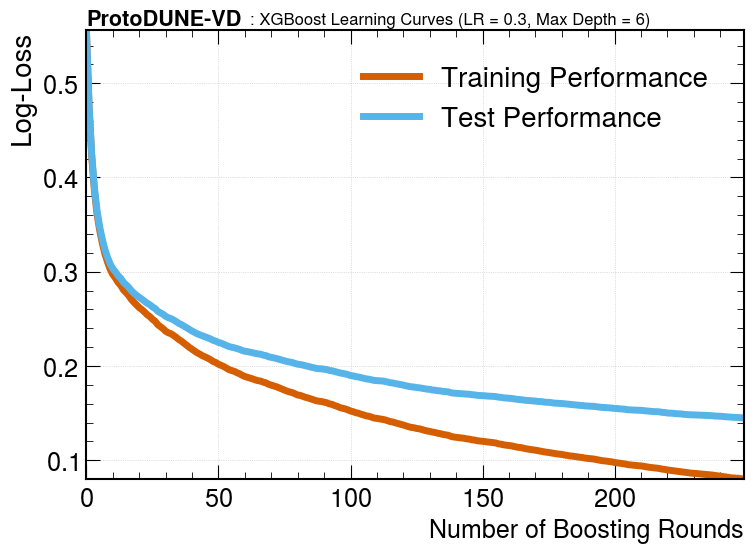

In [7]:
results = bdt_model_plane2.evals_result()
epochs = len(results['validation_0']['logloss'])
epochs_test = len(results['validation_1']['logloss'])
x_axis = range(0, epochs)

# Plot the AUCPR values
plt.figure(figsize=(8, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Training Performance', linewidth=5)
plt.plot(x_axis, results['validation_1']['logloss'], label='Test Performance', linewidth=5)
plt.legend(fontsize=20)
plt.xlabel('Number of Boosting Rounds', fontsize=18)
plt.ylabel('Log-Loss', fontsize=20)
plt.grid()
#plt.title('XGBoost Plane 2 PD-VD Model Log-Loss Performance', fontsize=20)
hep.dune.label(f': XGBoost Learning Curves (LR = 0.3, Max Depth = 6)', rlabel='', fontsize=12, exp='ProtoDUNE-VD', data=True)
#plt.savefig('/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_xgboost_learning_curves_6d_0p3lr_mar2026.pdf', format="pdf")
plt.show()

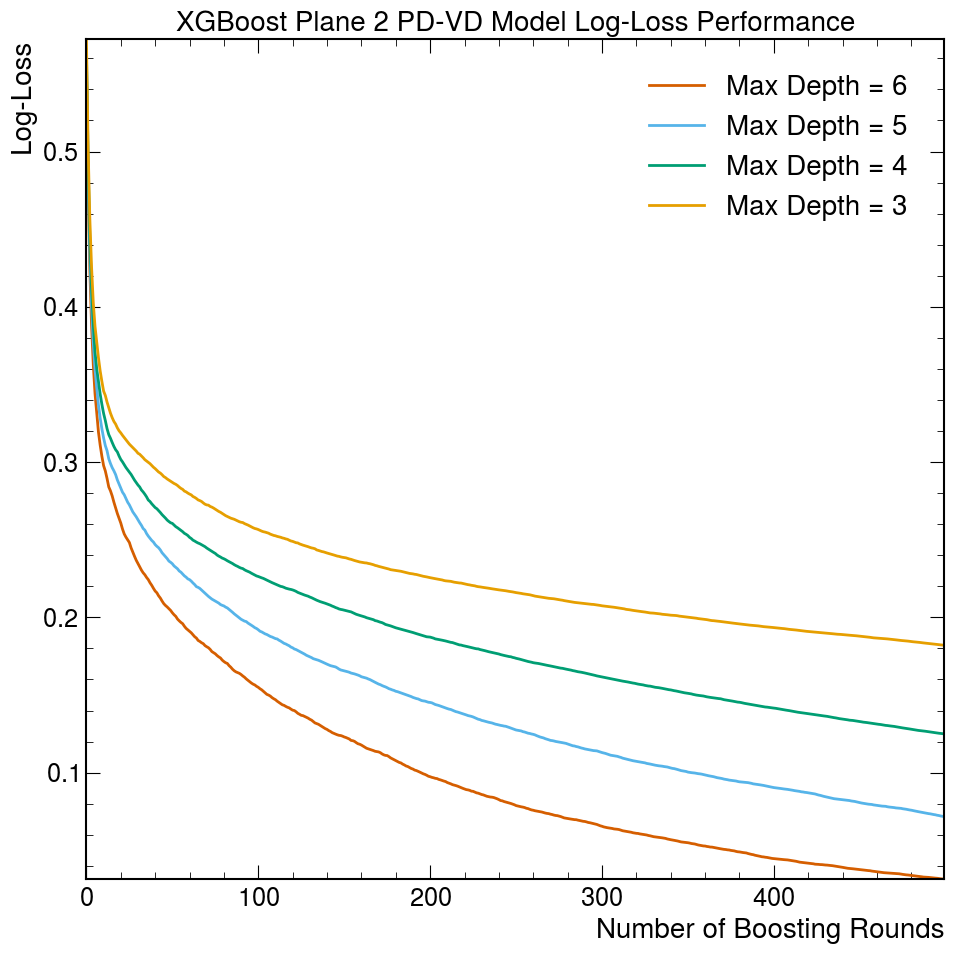

In [107]:
results = bdt_model_plane2.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

results_m5 = bdt_model_plane2_m5.evals_result()
epochs_m5 = len(results_m5['validation_0']['logloss'])
x_axis_m5 = range(0, epochs_m5)

results_m4 = bdt_model_plane2_m4.evals_result()
epochs_m4 = len(results_m4['validation_0']['logloss'])
x_axis_m4 = range(0, epochs_m4)

results_m3 = bdt_model_plane2_m3.evals_result()
epochs_m3 = len(results_m3['validation_0']['logloss'])
x_axis_m3 = range(0, epochs_m3)

# Plot the AUCPR values
plt.figure()
plt.plot(x_axis, results['validation_0']['logloss'], label='Max Depth = 6')
plt.plot(x_axis_m5, results_m5['validation_0']['logloss'], label='Max Depth = 5')
plt.plot(x_axis_m4, results_m4['validation_0']['logloss'], label='Max Depth = 4')
plt.plot(x_axis_m3, results_m3['validation_0']['logloss'], label='Max Depth = 3')
plt.legend(fontsize=20)
plt.xlabel('Number of Boosting Rounds', fontsize=20)
plt.ylabel('Log-Loss', fontsize=20)
plt.title('XGBoost Plane 2 PD-VD Model Log-Loss Performance', fontsize=20)
plt.show()

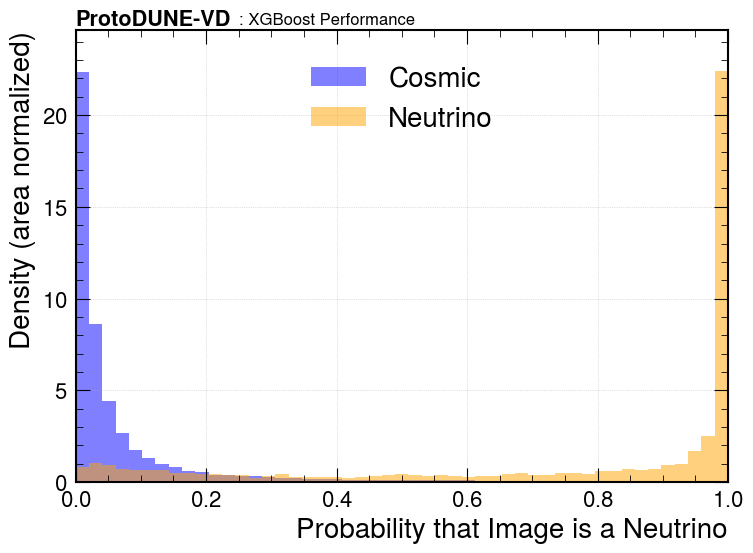

In [8]:
Y_cos_nu_plane2_prob_results = bdt_model_plane2.predict_proba(X_features_plane2_test)[:, 1]

Y_cos_nu_plane2_test_flat = Y_cos_nu_plane2_test.flatten()
# Separate scores by true label
scores_cosmic   = Y_cos_nu_plane2_prob_results[Y_cos_nu_plane2_test_flat == 0]
scores_neutrino = Y_cos_nu_plane2_prob_results[Y_cos_nu_plane2_test_flat == 1]

# Plot histogram
fig, axs = plt.subplots(1, 1, figsize=(8, 6)) #plt.figure(figsize=(8, 5))
bins = np.linspace(0, 1, 50)

plt.hist(scores_cosmic, bins=bins, density=True, alpha=0.5, label='Cosmic', color='blue')
plt.hist(scores_neutrino, bins=bins, density=True, alpha=0.5, label='Neutrino', color='orange')

plt.xlabel("Probability that Image is a Neutrino",fontsize=20)
plt.ylabel("Density (area normalized)",fontsize=20)
#(Trees = 250, Max Depth = 6)
hep.dune.label(f': XGBoost Performance', rlabel='', fontsize=12, exp='ProtoDUNE-VD', ax=axs, data=True)
#plt.title(r"XGBoost (Channel $\times$ Time) Plane 2; DUNE Work in Progress",fontsize=16)
plt.legend(loc='upper center',fontsize=20)
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.margins(y=0.1)
#plt.tight_layout()

#plt.yscale('log')
plt.savefig('/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_xgboost_probability_101el_final_model_250t_6d_0p3lr_mar26.pdf', format="pdf")
plt.show()

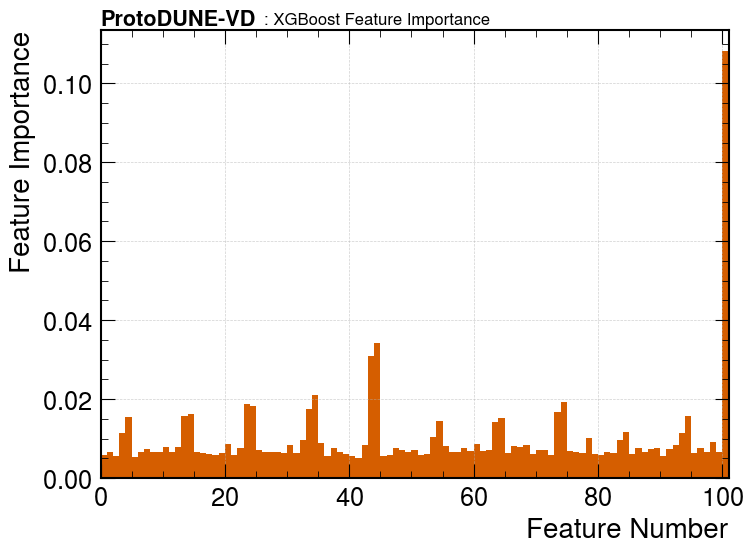

In [9]:
# Test feature importance of XGBoost 2D input model

bdt_plane2_model_feature_importance = bdt_model_plane2.feature_importances_

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

h_imp = Hist.new.Reg(bdt_plane2_model_feature_importance.shape[0], 0, 
                     bdt_plane2_model_feature_importance.shape[0], 
                     name="feature_importance", label='Feature Number').Double()
        
h_imp.view(flow=False)[:] = bdt_plane2_model_feature_importance
            
hep.histplot(h_imp, histtype='fill', ax=ax)
ax.margins(y=0.05)
ax.set_ylabel('Feature Importance')
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Feature Number",fontsize=20)
plt.ylabel("Feature Importance",fontsize=20)

#plt.title(r"XGBoost (Channel $\times$ Time) Input; DUNE Work in Progress",fontsize=16)
hep.dune.label(f': XGBoost Feature Importance', rlabel='', fontsize=12, exp='ProtoDUNE-VD', ax=ax, data=True)
#plt.savefig('/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_xgboost_101el_total_feature_importance_mar2026.pdf', format="pdf")

plt.show()

<class 'mplhep.plot.ColormeshArtists'> ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f9146474d70>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f9146475a90>, text=[])


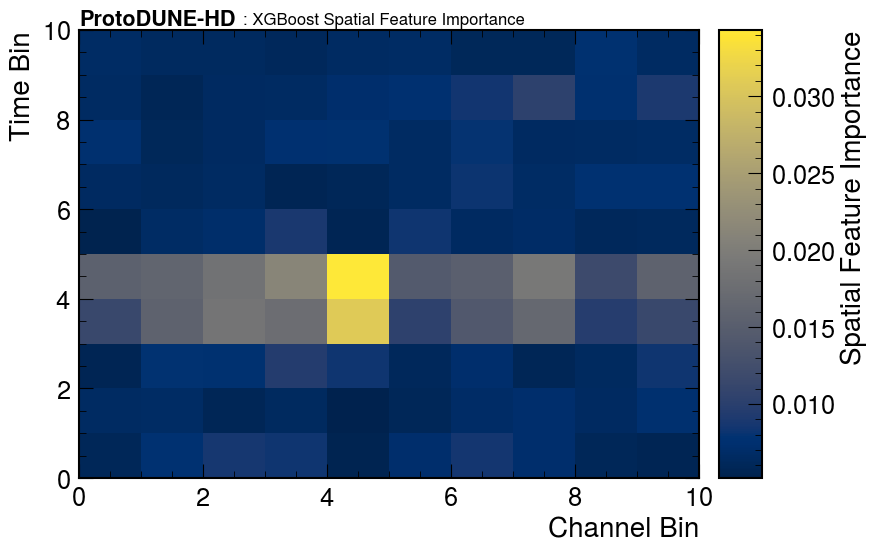

In [10]:
# Get the 1D values back
values_1d = bdt_plane2_model_feature_importance[:100]

# Reshape back to 10x10 using SAME order='C'
values_2d = values_1d.reshape((10, 10), order='C')

h2_imp = (
    Hist.new
    .Reg(10, 0, 10, name="channel", label="Channel Bin")
    .Reg(10, 0, 10, name="time", label="Time Bin")
    .Double()
)

# Fill the histogram storage directly
h2_imp.view(flow=False)[:, :] = values_2d

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

image = hep.hist2dplot(h2_imp, ax=ax)
print(type(image), image)
cbar = image.cbar


plt.xlabel("Channel Bin",fontsize=20)
plt.ylabel("Time Bin",fontsize=20)
cbar.set_label("Spatial Feature Importance", fontsize=20)
formatter = ticker.ScalarFormatter(useMathText=True)
#formatter.set_powerlimits((0, 0))   # always use scientific notation

cbar.formatter = formatter
cbar.update_ticks()
#ax.margins(y=0.05)
#ax.set_ylabel('Feature Importance')
#plt.grid(True, linestyle="--", alpha=0.6)

#plt.title(r"XGBoost (Channel $\times$ Time) Feature Importance; DUNE Work in Progress",fontsize=16)
hep.dune.label(f': XGBoost Spatial Feature Importance', rlabel='', fontsize=12, exp='ProtoDUNE-HD', ax=ax, data=True)
#plt.savefig('/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_xgboost_101el_2d_spatial_feature_importance_mar2026.pdf', format="pdf")

plt.show()

In [11]:
cosmic_adc_sum = np.sum(cosmic_images_plane2, axis=(1, 2))
neutrino_adc_sum = np.sum(nu_images_plane2, axis=(1, 2))
print(f'cosmic_adc_sum shape = {cosmic_adc_sum.shape}')

cosmic_adc_sum shape = (263001,)


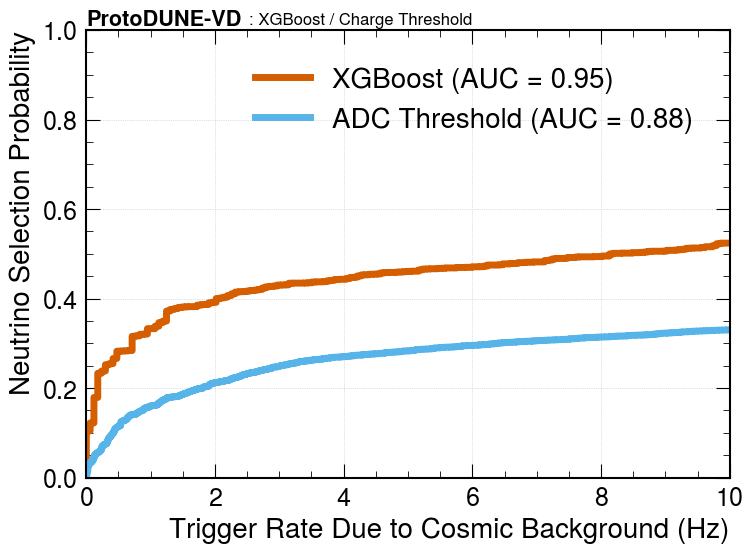

In [12]:
# Plot a ROC Curve for comparison between different models to use in trigger
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
#import tl2cgen

# conversion not perfect, but gives a rough idea
# 0.00030625 chance of 0.3ms window of cosmics triggering at 1Hz
# bkgd_rate_hz_conversion = 0.00030625
bkgd_rate_hz_conversion = 0.00032
DoHz = True

# Classical case
y_scores_classical = np.concatenate([neutrino_adc_sum, cosmic_adc_sum])
y_true_classical = np.concatenate([np.ones_like(neutrino_adc_sum), np.zeros_like(cosmic_adc_sum)])

# XGBoost models for each plane
Y_cos_nu_plane2_prob_results = bdt_model_plane2.predict_proba(X_features_plane2_test)[:, 1]
#Y_cos_nu_plane1_prob_results = bdt_model_plane1.predict_proba(X_features_plane1_test)[:, 1]
#Y_cos_nu_plane0_prob_results = bdt_model_plane0.predict_proba(X_features_plane0_test)[:, 1]

# XGBoost model with prior fiducial image cut
#Y_cos_nu_plane2_cut_prob_results = bdt_model_plane2_cut.predict_proba(X_features_plane2_cut_test)[:, 1]

# Classical: assume higher charge = more signal-like
fpr_classical, tpr_classical, thresholds_classical = roc_curve(y_true_classical, y_scores_classical)
auc_classical = auc(fpr_classical, tpr_classical)
if DoHz:
    fpr_classical = fpr_classical / bkgd_rate_hz_conversion

# XGBoost plane 2
fpr_bdt_p2, tpr_bdt_p2, thresholds_bdt_p2 = roc_curve(Y_cos_nu_plane2_test, Y_cos_nu_plane2_prob_results)
auc_bdt_p2 = auc(fpr_bdt_p2, tpr_bdt_p2)
if DoHz:
    fpr_bdt_p2 = fpr_bdt_p2 / bkgd_rate_hz_conversion

# XGBoost plane 1
#fpr_bdt_p1, tpr_bdt_p1, thresholds_bdt_p1 = roc_curve(Y_cos_nu_plane1_test, Y_cos_nu_plane1_prob_results)
#auc_bdt_p1 = auc(fpr_bdt_p1, tpr_bdt_p1)
#if DoHz:
#    fpr_bdt_p1 = fpr_bdt_p1 / bkgd_rate_hz_conversion
    
# XGBoost plane 0
#fpr_bdt_p0, tpr_bdt_p0, thresholds_bdt_p0 = roc_curve(Y_cos_nu_plane0_test, Y_cos_nu_plane0_prob_results)
#auc_bdt_p0 = auc(fpr_bdt_p0, tpr_bdt_p0)
#if DoHz:
#    fpr_bdt_p0 = fpr_bdt_p0 / bkgd_rate_hz_conversion

# XGBoost plane 2 with prior fiducial cut
#fpr_bdt_p2_cut, tpr_bdt_p2_cut, thresholds_bdt_p2_cut = roc_curve(Y_cos_nu_plane2_cut_test, Y_cos_nu_plane2_cut_prob_results)
#auc_bdt_p2_cut = auc(fpr_bdt_p2_cut, tpr_bdt_p2_cut)
#fpr_bdt_p2_cut = fpr_bdt_p2_cut * cosmic_cut_eff
#tpr_bdt_p2_cut = tpr_bdt_p2_cut * neutrino_cut_eff
#if DoHz:
#    fpr_bdt_p2_cut = fpr_bdt_p2_cut / bkgd_rate_hz_conversion

    
# Plot ROC Curve Comparison
plt.figure(figsize=(8, 6))

plt.plot(fpr_bdt_p2, tpr_bdt_p2, label=f'XGBoost (AUC = {auc_bdt_p2:.2f})', linewidth=5)
#plt.plot(fpr_bdt_p1, tpr_bdt_p1, label=f'XGBoost P1 (AUC = {auc_bdt_p1:.2f})')
#plt.plot(fpr_bdt_p0, tpr_bdt_p0, label=f'XGBoost P0 (AUC = {auc_bdt_p0:.2f})')
#plt.plot(fpr_bdt_p2_cut, tpr_bdt_p2_cut, label=f'XGBoost P2 Cut (AUC = {auc_bdt_p2_cut:.2f})')
plt.plot(fpr_classical, tpr_classical, label=f'ADC Threshold (AUC = {auc_classical:.2f})', linewidth=5)

if not DoHz:
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (chance)
if DoHz:
    plt.xlabel('Trigger Rate Due to Cosmic Background (Hz)', fontsize=20)
else:
    plt.xlabel('False Positive Rate', fontsize=18)
plt.ylabel('Neutrino Selection Probability', fontsize=20)
#plt.title('ROC Curve Trigger Comparison; DUNE Work in Progress', fontsize=18)
hep.dune.label(f': XGBoost / Charge Threshold', rlabel='', fontsize=12, exp='ProtoDUNE-VD', data=True) 
plt.legend(loc='upper right', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
if DoHz:
    plt.xlim(0, 10)
else:
    plt.xlim(0, 0.01)
    #plt.xlim(0, 0.002)
plt.grid()
plt.tight_layout()
#plt.savefig('/eos/user/c/chasnip/DUNE/ProtoDUNE_BSM/TADevelopPlots/pdvd_roc_curve_xgboost_adcsw_comparison_hznarrowaxis_101el_model_250t_6d_0p3lr_mar26.pdf', format="pdf")
plt.show()

In [140]:
if DoHz:
    desired_fpr = 2
else:
    desired_fpr = 0.0003

# Find the index of the closest FPR
idx_bdt_p2 = np.argmin(np.abs(fpr_bdt_p2 - desired_fpr))
# Get the corresponding threshold
threshold_at_desired_fpr_bdt_p2 = thresholds_bdt_p2[idx_bdt_p2]
print(f"Threshold at FPR for plane 2 XGBoost ≈ {desired_fpr}: {threshold_at_desired_fpr_bdt_p2}")
print(f"Signal selection rate for BDT theshold {threshold_at_desired_fpr_bdt_p2} : {tpr_bdt_p2[idx_bdt_p2]}")


# Find the index of the closest FPR
idx_classical = np.argmin(np.abs(fpr_classical - desired_fpr))
# Get the corresponding threshold
threshold_at_desired_fpr_classical = thresholds_classical[idx_classical]
print(f"Threshold at FPR for ADCSimpleWindow ≈ {desired_fpr}: {threshold_at_desired_fpr_classical}")
print(f"Signal selection rate for theshold {threshold_at_desired_fpr_classical} : {tpr_classical[idx_classical]}")

Threshold at FPR for plane 2 XGBoost ≈ 2: 0.9929805994033813
Signal selection rate for BDT theshold 0.9929805994033813 : 0.38481272447408926
Threshold at FPR for ADCSimpleWindow ≈ 2: 11413431.0
Signal selection rate for theshold 11413431.0 : 0.21173038538308


In [18]:
print(type(bdt_model_plane2))
#bdt_model_plane2.save_model('./pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.json')
bdt_model_plane2.get_booster().save_model(
    "./pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.json"
)

<class 'xgboost.sklearn.XGBClassifier'>


In [20]:
import treelite


treelite_2d_model = treelite.frontend.load_xgboost_model("./pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.json")

import tl2cgen

toolchain = "gcc" 
tl2cgen.export_lib(treelite_2d_model, toolchain=toolchain, libpath="./treelite_pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.so")
tl2cgen_2dpredictor = tl2cgen.Predictor("./treelite_pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.so")

tl2cgen.export_srcpkg(treelite_2d_model, toolchain=toolchain,
                      pkgpath="./treelite_pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.zip", libname="treelite_pdvd_nu_cosmicoverlay_cosmic_xgboost_250t_6d_0p3LR_mar2026.so")

[16:24:17] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0


[16:24:17] /project/src/compiler/ast/split.cc:30: Parallel compilation disabled; all member trees will be dumped to a single source file. This may increase compilation time and memory usage.
[16:24:38] /project/src/compiler/ast/split.cc:30: Parallel compilation disabled; all member trees will be dumped to a single source file. This may increase compilation time and memory usage.


[16:24:38] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0
